In [1]:
# 1. Import Library
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import os


In [2]:
# 2. Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Shape Gambar Data Latih: (60000, 28, 28)
Shape Label Data Latih: (60000,)


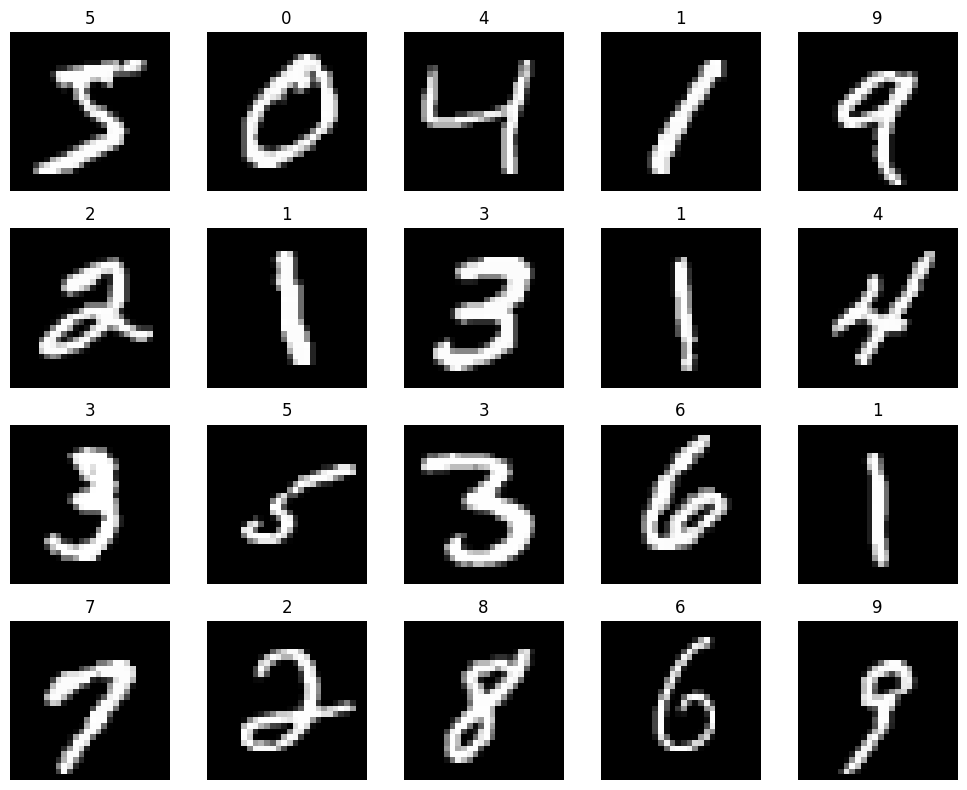

In [3]:
# 3. Load Dataset Vision
from src.image_loader import load_mnist_images, load_mnist_labels

# 3.1. Load data latih dan data uji dari file yang sudah di download
x_train = load_mnist_images("dataset/image/train-images-idx3-ubyte")
y_train = load_mnist_labels("dataset/image/train-labels-idx1-ubyte")

x_test = load_mnist_images("dataset/image/t10k-images-idx3-ubyte")
y_test = load_mnist_labels("dataset/image/t10k-labels-idx1-ubyte")

# 3.2. Print shape atau bentuk gambar dan label data latih
print(f"Shape Gambar Data Latih: {x_train.shape}")
print(f"Shape Label Data Latih: {y_train.shape}")

# 3.3. Menunjukkan contoh sampel gambar data latih beserta labelnya
rows = 4
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

for i in range(rows * cols):
    r = i // cols
    c = i % cols

    axes[r, c].imshow(x_train[i], cmap='gray')
    axes[r, c].set_title(y_train[i])
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 4. Preprocessing Dataset Vision
from src.image_preprocessor import preprocess_mnist

# 4.1. Melakukan preprocessing terhadap data latih
x_train, y_train = preprocess_mnist(
    x_train,
    y_train,
    normalize=True,
    flatten=True,
    one_hot=False
)

# 4.2. Menunjukkan contoh sampel gambar data latih beserta labelnya yang sudah di preprocess
print(f"Shape Gambar Data Latih (Preprocessed): {x_train.shape}")
print(f"Shape Label Data Latih (Preprocessed): {y_train.shape}")

# 4.3. Mengubah x_train dan y_train menjadi bentuk tensor untuk dijadikan tensor dataset
x_train_tensor = torch.tensor(
    x_train,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long,
)

# 4.4. Menjadikan x_train_tensor dan y_train_tensor menjadi tensor dataset
train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor,
)

# 4.5. Menjadikan train_dataset menjadi sebuah data loader untuk di training
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)


Shape Gambar Data Latih (Preprocessed): (60000, 784)
Shape Label Data Latih (Preprocessed): (60000,)


### 5. Definisi Model Generatif Vision
# TODO - Menambah definisi model generatif Vision

### 6. Penjelasan Rumus Model Vision
# TODO - Menambah penjelasan untuk tiap konsep

#### 6.1. Konsep Dasar Generative Model
Model generatif berusaha mempelajari distribusi data:

$$
p(x)
$$

atau distribusi bersyarat:

$$
p(x|c)
$$

- $x$ = data yang ingin dihasilkan, misalnya gambar atau teks.  
- $c$ = kondisi, misalnya prompt, label, atau input tertentu.  
- $p(x)$ = peluang kemunculan data.  
- $p(x|c)$ = peluang menghasilkan data berdasarkan kondisi tertentu.

##### Penjelasan:

#### 6.2. Autoencoder

$$
z = f_{\theta}(x)
$$

$$
\hat{x} = g_{\phi}(z)
$$

$$
L = \|x - \hat{x}\|^2
$$

- $x$ = input asli.  
- $z$ = latent vector.  
- $\hat{x}$ = hasil rekonstruksi.  
- $f_{\theta}$ = encoder.  
- $g_{\phi}$ = decoder.  
- $L$ = reconstruction loss.

#### 6.3. Variational Autoencoder
$$
q_{\phi}(z|x)
$$

$$
z = \mu + \sigma \cdot \epsilon
$$

$$
\epsilon \sim \mathcal{N}(0, I)
$$

$$
L = L_{\text{reconstruction}} + L_{KL}
$$

$$
L_{KL} = D_{KL}(q_{\phi}(z|x) \parallel p(z))
$$

- $\mu$ = mean latent.  
- $\sigma$ = standar deviasi latent.  
- $\epsilon$ = noise acak.  
- $q_{\phi}(z|x)$ = distribusi latent dari input.  
- $p(z)$ = distribusi prior, biasanya normal standar.  
- $D_{KL}$ = KL divergence.

#### 6.4. Generative Adversarial Network (GAN)

$$
\min_G \max_D V(D, G)
$$

$$
V(D,G)=\mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

- $G$ = generator.  
- $D$ = discriminator.  
- $x$ = data asli.  
- $z$ = noise acak.  
- $G(z)$ = data palsu yang dibuat generator.  
- $D(x)$ = probabilitas data dianggap asli.

#### 6.5. Diffusion Model

$$
x_t = \sqrt{\alpha_t} x_0 + \sqrt{1 - \alpha_t}\,\epsilon
$$

$$
\epsilon \sim \mathcal{N}(0, I)
$$

$$
L = \|\epsilon - \epsilon_{\theta}(x_t, t)\|^2
$$

- $x_0$ = gambar asli.  
- $x_t$ = gambar yang sudah diberi noise.  
- $\epsilon$ = noise asli.  
- $\epsilon_{\theta}$ = noise yang diprediksi model.  
- $t$ = timestep.  
- $\alpha_t$ = koefisien noise.


In [5]:
# Membuat folder untuk menyimpan semua gambar dan hasil eksperimen (berlaku untuk teks juga)
def get_timestamp() -> str:
    return datetime.now().strftime("%Y%m%d-%H%M%S")

def create_folder(path:str) -> str:
    os.makedirs(path, exist_ok=True)
    return path

run_path = create_folder(f"outputs/run-{get_timestamp()}")

Training VAE-5e-64ld
Epoch [1] | kl_loss: 0.000091 | loss: 0.070271 | recon_loss: 0.070180

=== Epoch 1/5 ===
  Epoch Time: 3.19s
Epoch [2] | kl_loss: 0.000050 | loss: 0.067559 | recon_loss: 0.067509

=== Epoch 2/5 ===
  Epoch Time: 2.97s
Epoch [3] | kl_loss: 0.000041 | loss: 0.067488 | recon_loss: 0.067447

=== Epoch 3/5 ===
  Epoch Time: 2.90s
Epoch [4] | kl_loss: 0.000033 | loss: 0.067434 | recon_loss: 0.067401

=== Epoch 4/5 ===
  Epoch Time: 2.89s
Epoch [5] | kl_loss: 0.000026 | loss: 0.067391 | recon_loss: 0.067364

=== Epoch 5/5 ===
  Epoch Time: 2.90s

=== Training Complete ===
  Total Time: 14.84s (0.25m)
Model saved to: outputs/run-20260509-131935/image/VAE-5e-64ld/checkpoints


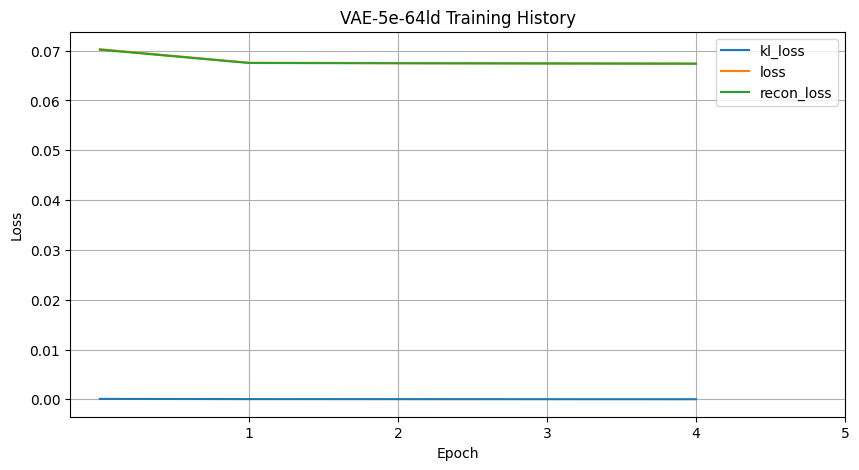

Training VAE-5e-128ld
Epoch [1] | kl_loss: 0.000318 | loss: 0.070231 | recon_loss: 0.069913

=== Epoch 1/5 ===
  Epoch Time: 2.82s
Epoch [2] | kl_loss: 0.001318 | loss: 0.067226 | recon_loss: 0.065908

=== Epoch 2/5 ===
  Epoch Time: 2.88s
Epoch [3] | kl_loss: 0.001544 | loss: 0.067060 | recon_loss: 0.065516

=== Epoch 3/5 ===
  Epoch Time: 2.88s
Epoch [4] | kl_loss: 0.001619 | loss: 0.066988 | recon_loss: 0.065369

=== Epoch 4/5 ===
  Epoch Time: 2.89s
Epoch [5] | kl_loss: 0.001751 | loss: 0.066841 | recon_loss: 0.065090

=== Epoch 5/5 ===
  Epoch Time: 2.87s

=== Training Complete ===
  Total Time: 14.34s (0.24m)
Model saved to: outputs/run-20260509-131935/image/VAE-5e-128ld/checkpoints


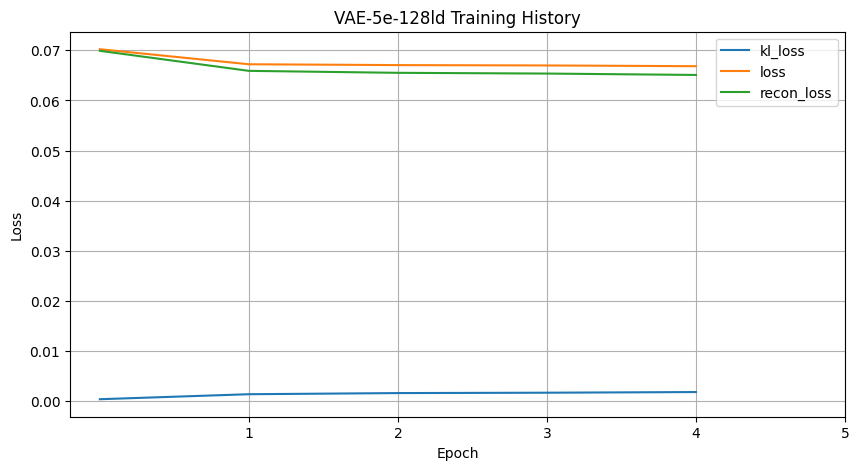

Training VAE-20e-64ld
Epoch [1] | kl_loss: 0.000092 | loss: 0.070251 | recon_loss: 0.070159

=== Epoch 1/20 ===
  Epoch Time: 2.85s
Epoch [2] | kl_loss: 0.000050 | loss: 0.067556 | recon_loss: 0.067506

=== Epoch 2/20 ===
  Epoch Time: 2.93s
Epoch [3] | kl_loss: 0.000043 | loss: 0.067474 | recon_loss: 0.067431

=== Epoch 3/20 ===
  Epoch Time: 2.93s
Epoch [4] | kl_loss: 0.000036 | loss: 0.067412 | recon_loss: 0.067376

=== Epoch 4/20 ===
  Epoch Time: 2.85s
Epoch [5] | kl_loss: 0.000020 | loss: 0.067395 | recon_loss: 0.067375

=== Epoch 5/20 ===
  Epoch Time: 2.87s
Epoch [6] | kl_loss: 0.000015 | loss: 0.067370 | recon_loss: 0.067355

=== Epoch 6/20 ===
  Epoch Time: 2.90s
Epoch [7] | kl_loss: 0.000012 | loss: 0.067344 | recon_loss: 0.067332

=== Epoch 7/20 ===
  Epoch Time: 2.88s
Epoch [8] | kl_loss: 0.000008 | loss: 0.067324 | recon_loss: 0.067316

=== Epoch 8/20 ===
  Epoch Time: 2.82s
Epoch [9] | kl_loss: 0.000007 | loss: 0.067319 | recon_loss: 0.067312

=== Epoch 9/20 ===
  Epoch 

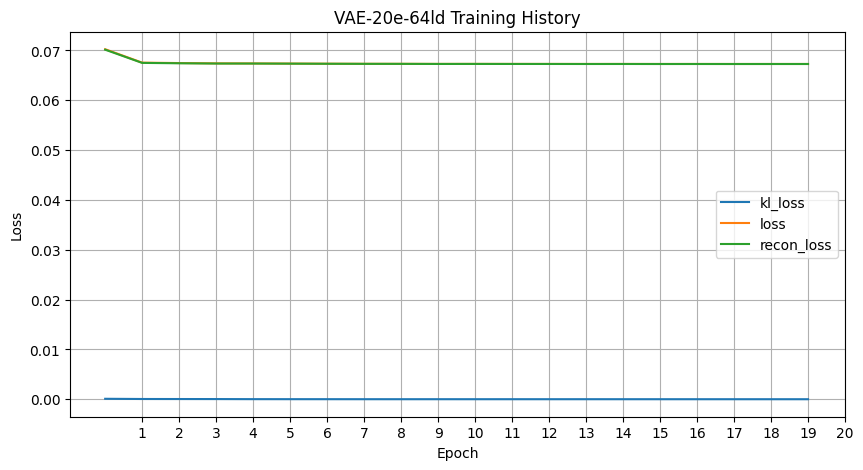

Training VAE-20e-128ld
Epoch [1] | kl_loss: 0.000426 | loss: 0.070172 | recon_loss: 0.069746

=== Epoch 1/20 ===
  Epoch Time: 2.86s
Epoch [2] | kl_loss: 0.001438 | loss: 0.067143 | recon_loss: 0.065705

=== Epoch 2/20 ===
  Epoch Time: 2.91s
Epoch [3] | kl_loss: 0.001513 | loss: 0.066984 | recon_loss: 0.065471

=== Epoch 3/20 ===
  Epoch Time: 2.89s
Epoch [4] | kl_loss: 0.001513 | loss: 0.066952 | recon_loss: 0.065439

=== Epoch 4/20 ===
  Epoch Time: 2.91s
Epoch [5] | kl_loss: 0.001573 | loss: 0.066943 | recon_loss: 0.065370

=== Epoch 5/20 ===
  Epoch Time: 2.86s
Epoch [6] | kl_loss: 0.001573 | loss: 0.066877 | recon_loss: 0.065304

=== Epoch 6/20 ===
  Epoch Time: 2.88s
Epoch [7] | kl_loss: 0.001564 | loss: 0.066874 | recon_loss: 0.065311

=== Epoch 7/20 ===
  Epoch Time: 2.79s
Epoch [8] | kl_loss: 0.001558 | loss: 0.066879 | recon_loss: 0.065321

=== Epoch 8/20 ===
  Epoch Time: 2.86s
Epoch [9] | kl_loss: 0.001573 | loss: 0.066819 | recon_loss: 0.065246

=== Epoch 9/20 ===
  Epoch

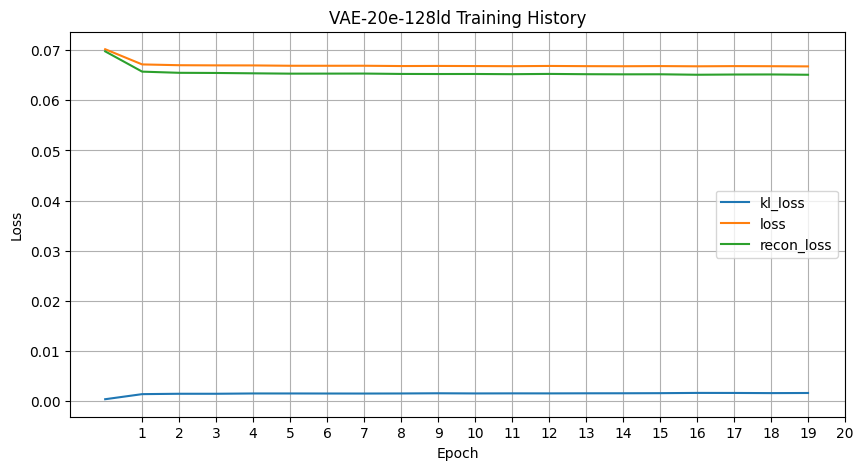

Training GAN-5e-64ld
Epoch [1] | d_loss: 0.307704 | g_loss: 3.164012

=== Epoch 1/5 ===
  Epoch Time: 4.17s
Epoch [2] | d_loss: 0.020205 | g_loss: 5.764264

=== Epoch 2/5 ===
  Epoch Time: 4.18s
Epoch [3] | d_loss: 0.008743 | g_loss: 6.855556

=== Epoch 3/5 ===
  Epoch Time: 3.97s
Epoch [4] | d_loss: 0.009524 | g_loss: 7.653436

=== Epoch 4/5 ===
  Epoch Time: 4.07s
Epoch [5] | d_loss: 0.012290 | g_loss: 8.342115

=== Epoch 5/5 ===
  Epoch Time: 3.98s

=== Training Complete ===
  Total Time: 20.38s (0.34m)
Model saved to: outputs/run-20260509-131935/image/GAN-5e-64ld/checkpoints


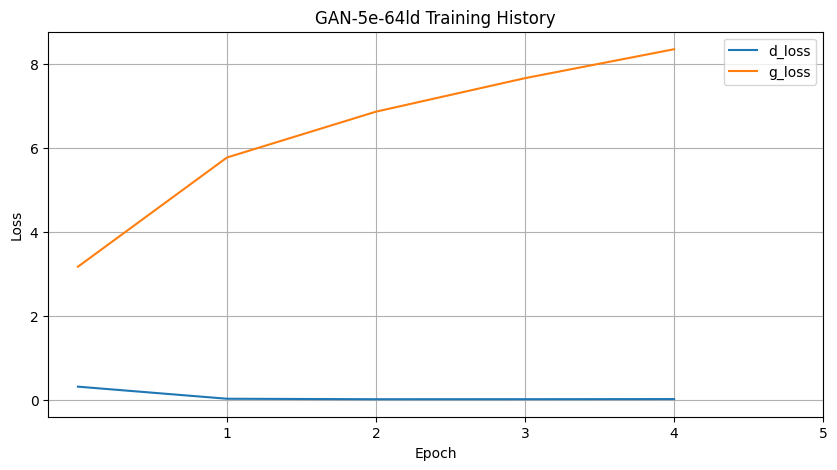

Training GAN-5e-128ld
Epoch [1] | d_loss: 0.321870 | g_loss: 3.037292

=== Epoch 1/5 ===
  Epoch Time: 4.16s
Epoch [2] | d_loss: 0.018578 | g_loss: 5.837060

=== Epoch 2/5 ===
  Epoch Time: 4.12s
Epoch [3] | d_loss: 0.008270 | g_loss: 6.548168

=== Epoch 3/5 ===
  Epoch Time: 4.12s
Epoch [4] | d_loss: 0.005950 | g_loss: 7.013229

=== Epoch 4/5 ===
  Epoch Time: 4.11s
Epoch [5] | d_loss: 0.005991 | g_loss: 8.390240

=== Epoch 5/5 ===
  Epoch Time: 4.06s

=== Training Complete ===
  Total Time: 20.57s (0.34m)
Model saved to: outputs/run-20260509-131935/image/GAN-5e-128ld/checkpoints


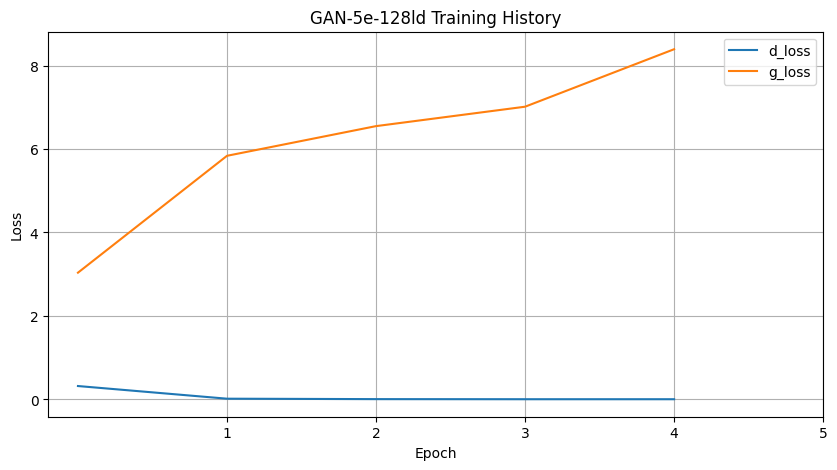

Training GAN-20e-64ld
Epoch [1] | d_loss: 0.310663 | g_loss: 3.079671

=== Epoch 1/20 ===
  Epoch Time: 4.15s
Epoch [2] | d_loss: 0.021387 | g_loss: 5.727771

=== Epoch 2/20 ===
  Epoch Time: 4.14s
Epoch [3] | d_loss: 0.008982 | g_loss: 6.896477

=== Epoch 3/20 ===
  Epoch Time: 4.11s
Epoch [4] | d_loss: 0.005708 | g_loss: 7.527018

=== Epoch 4/20 ===
  Epoch Time: 4.18s
Epoch [5] | d_loss: 0.008911 | g_loss: 9.270461

=== Epoch 5/20 ===
  Epoch Time: 4.15s
Epoch [6] | d_loss: 0.007098 | g_loss: 8.858648

=== Epoch 6/20 ===
  Epoch Time: 4.18s
Epoch [7] | d_loss: 0.005929 | g_loss: 8.213728

=== Epoch 7/20 ===
  Epoch Time: 4.13s
Epoch [8] | d_loss: 0.006949 | g_loss: 9.591193

=== Epoch 8/20 ===
  Epoch Time: 4.18s
Epoch [9] | d_loss: 0.091314 | g_loss: 15.848470

=== Epoch 9/20 ===
  Epoch Time: 4.12s
Epoch [10] | d_loss: 0.020979 | g_loss: 6.615184

=== Epoch 10/20 ===
  Epoch Time: 4.19s
Epoch [11] | d_loss: 0.010328 | g_loss: 6.963323

=== Epoch 11/20 ===
  Epoch Time: 4.15s
Epoch

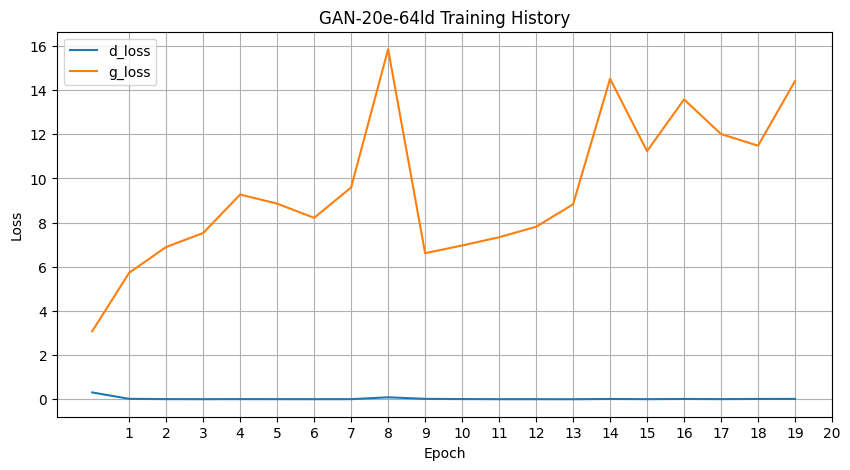

Training GAN-20e-128ld
Epoch [1] | d_loss: 0.320275 | g_loss: 3.091357

=== Epoch 1/20 ===
  Epoch Time: 4.19s
Epoch [2] | d_loss: 0.024551 | g_loss: 5.678575

=== Epoch 2/20 ===
  Epoch Time: 4.16s
Epoch [3] | d_loss: 0.009757 | g_loss: 6.713619

=== Epoch 3/20 ===
  Epoch Time: 4.07s
Epoch [4] | d_loss: 0.011095 | g_loss: 7.878470

=== Epoch 4/20 ===
  Epoch Time: 4.05s
Epoch [5] | d_loss: 0.005288 | g_loss: 7.473362

=== Epoch 5/20 ===
  Epoch Time: 4.11s
Epoch [6] | d_loss: 0.012885 | g_loss: 9.062088

=== Epoch 6/20 ===
  Epoch Time: 4.19s
Epoch [7] | d_loss: 0.010542 | g_loss: 9.207667

=== Epoch 7/20 ===
  Epoch Time: 4.18s
Epoch [8] | d_loss: 0.009797 | g_loss: 8.802590

=== Epoch 8/20 ===
  Epoch Time: 4.17s
Epoch [9] | d_loss: 0.010305 | g_loss: 9.283545

=== Epoch 9/20 ===
  Epoch Time: 4.14s
Epoch [10] | d_loss: 0.015106 | g_loss: 11.191383

=== Epoch 10/20 ===
  Epoch Time: 4.18s
Epoch [11] | d_loss: 0.009837 | g_loss: 12.775270

=== Epoch 11/20 ===
  Epoch Time: 4.17s
Epo

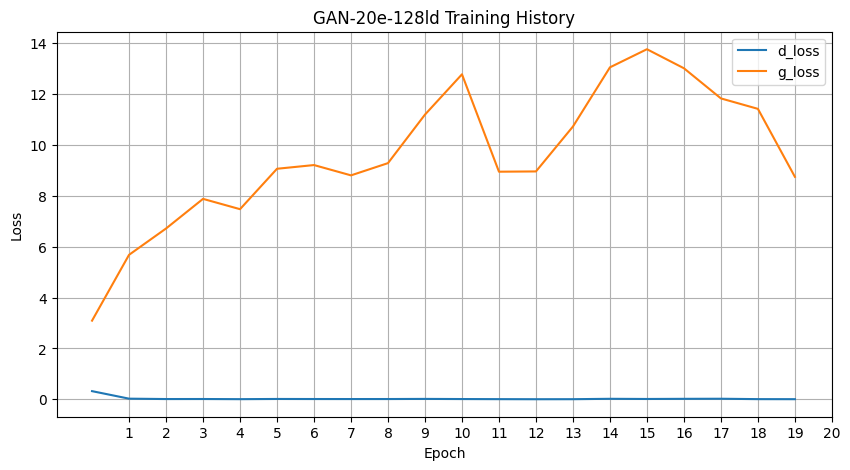

In [6]:
# 7. Training Model Vision
from src.image_generators import VAE, GAN

# 7.1. Membuat dictionary model yang digunakan beserta confignya
e5 = 5
e20 = 20
ld64 = 64
ld128 = 128

models = {
        f"VAE-{e5}e-{ld64}ld": {
            "model": VAE,
            "config": {
                'latent_dim': ld64,
                'hidden_dim': 128,
                'epochs': e5,
            },
        },
        f"VAE-{e5}e-{ld128}ld": {
            "model": VAE,
            "config": {
                'latent_dim': ld128,
                'hidden_dim': 128,
                'epochs': e5,
            },
        },
        f"VAE-{e20}e-{ld64}ld": {
            "model": VAE,
            "config": {
                'latent_dim': ld64,
                'hidden_dim': 128,
                'epochs': e20,
            },
        },
        f"VAE-{e20}e-{ld128}ld": {
            "model": VAE,
            "config": {
                'latent_dim': ld128,
                'hidden_dim': 128,
                'epochs': e20,
            },
        },
        f"GAN-{e5}e-{ld64}ld": {
            "model": GAN,
            "config": {
                'latent_dim': ld64,
                'hidden_dim': 128,
                'epochs': e5,
            }
        },
        f"GAN-{e5}e-{ld128}ld": {
            "model": GAN,
            "config": {
                'latent_dim': ld128,
                'hidden_dim': 128,
                'epochs': e5,
            }
        },
        f"GAN-{e20}e-{ld64}ld": {
            "model": GAN,
            "config": {
                'latent_dim': ld64,
                'hidden_dim': 128,
                'epochs': e20,
            }
        },
        f"GAN-{e20}e-{ld128}ld": {
            "model": GAN,
            "config": {
                'latent_dim': ld128,
                'hidden_dim': 128,
                'epochs': e20,
            }
        },
    }

# 7.2. Membuat dictionary history kosong untuk menyimpan semua hasil training eksperimen image generation
histories = {}

# 7.3.1. Membuat folder untuk menyimpan semua gambar dan hasil eksperimen khusus image
image_path = create_folder(f"{run_path}/image")

# 7.4. Melakukan proses training dan menyimpan hasil model beserta historynya kedalam dictionary histories
for exp_name, exp_data in models.items():

    model_class = exp_data["model"]
    config = exp_data["config"]

    model = model_class(
        input_dim=x_train.shape[1],
        latent_dim=config["latent_dim"],
        hidden_dim=config["hidden_dim"],
        device=device
    ).to(device)

    print("=" * 75)
    print(f"Training {exp_name}")
    print("=" * 75)

    # 7.4.1. Melakukan proses training dengan menunjukkan proses epoch beserta lossnya, dan diakhiri visualisasi grafik training history
    history = model.train_model(
        dataloader=train_loader,
        epochs=config["epochs"],
        verbose=True,
        save_path=f"{image_path}/{exp_name}/checkpoints",
    )

    history.plot(
        title=f"{exp_name} Training History",
        save_path=f"{image_path}/{exp_name}/{exp_name}_training_history.png"
    )

    histories[exp_name] = {
        "model": model,
        "history": history,
        "config": config,
    }


In [7]:
# 8. Generate Gambar Baru

# 8.1. Menentukan jumlah baris dan kolom visualisasi
rows = 4
cols = 5

# 8.2. Dictionary untuk menyimpan semua hasil generasi gambar
all_samples = {}

# 8.2. Melakukan generasi gambar masing masing yang sudah di untuk semua hasil generasi gambar
for exp_name, result in histories.items():

    model = result['model']

    samples = model.generate(rows * cols)

    print(
        f"Generated {len(samples)} images "
        f"from {exp_name}"
    )

    all_samples[exp_name] = samples

Generated 20 images from VAE-5e-64ld
Generated 20 images from VAE-5e-128ld
Generated 20 images from VAE-20e-64ld
Generated 20 images from VAE-20e-128ld
Generated 20 images from GAN-5e-64ld
Generated 20 images from GAN-5e-128ld
Generated 20 images from GAN-20e-64ld
Generated 20 images from GAN-20e-128ld


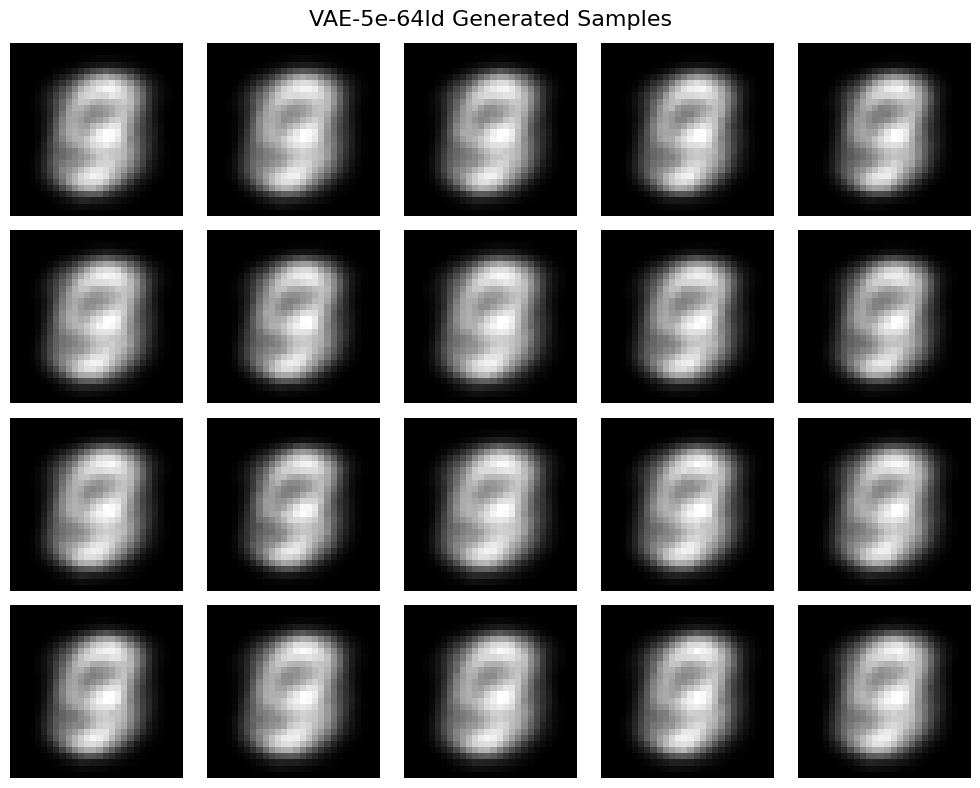

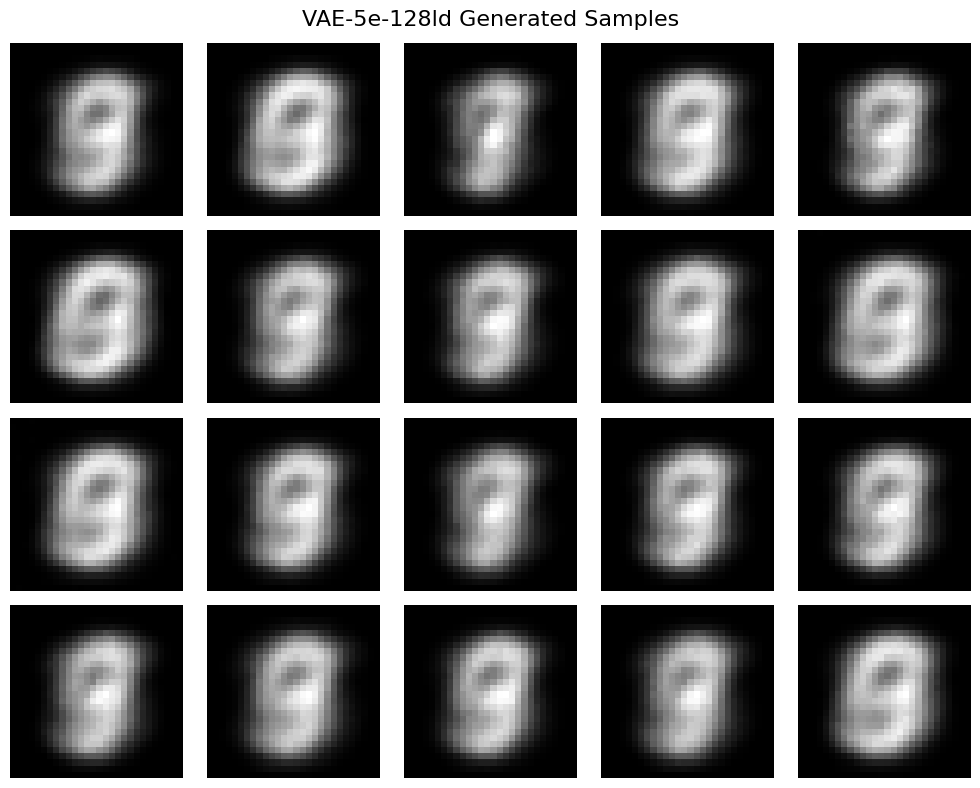

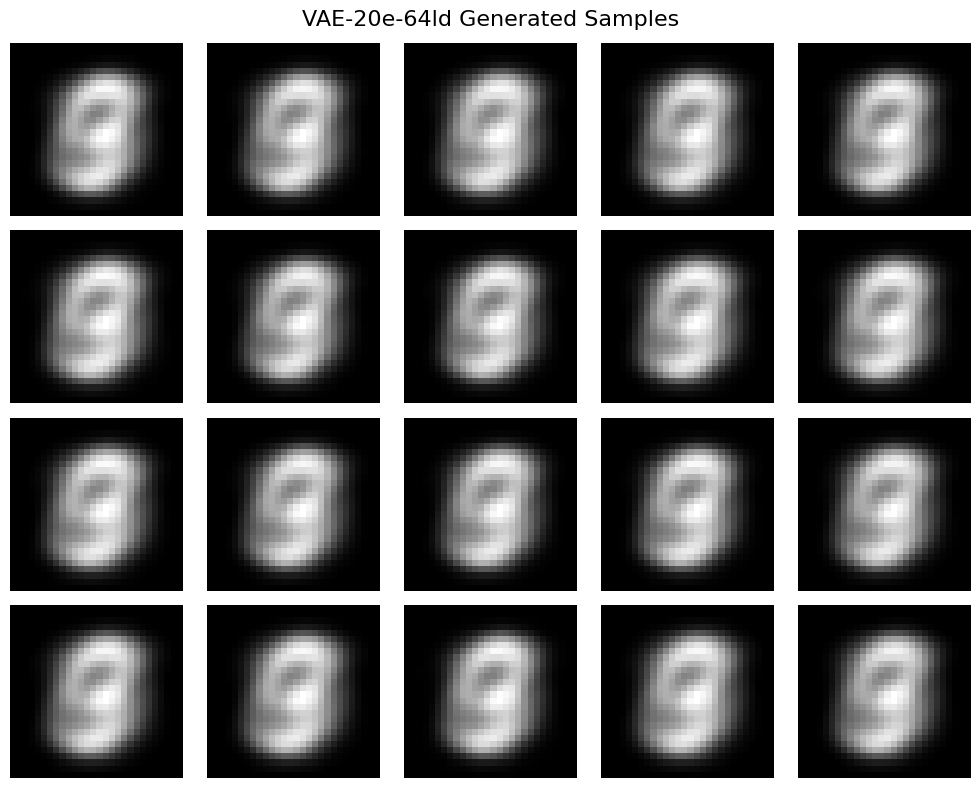

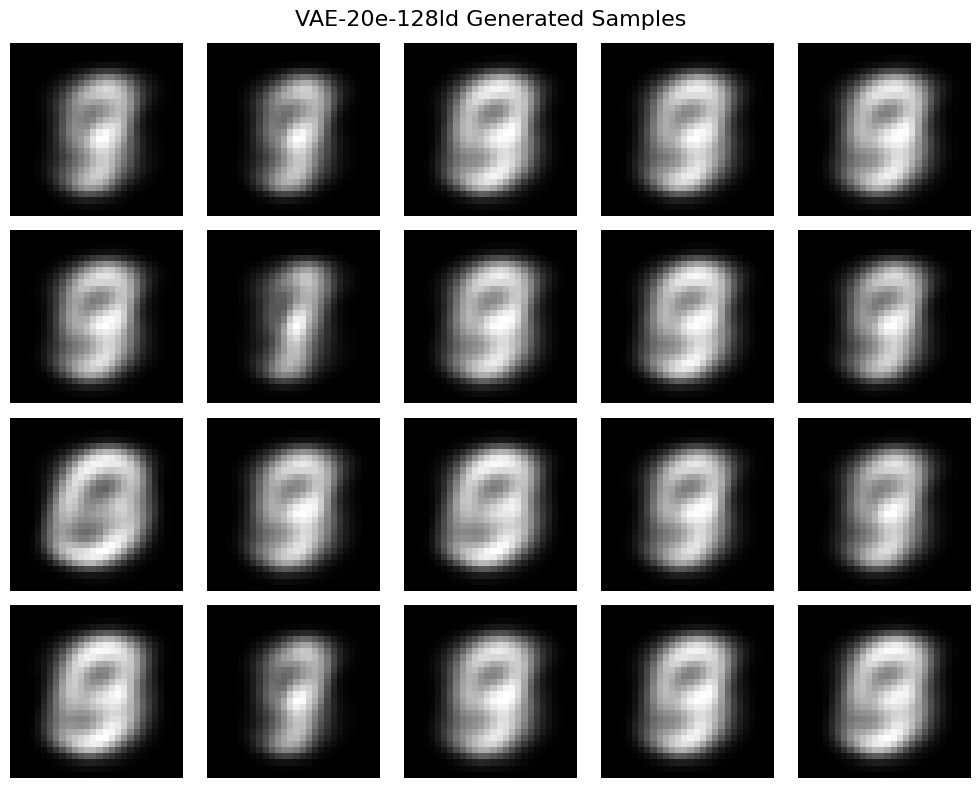

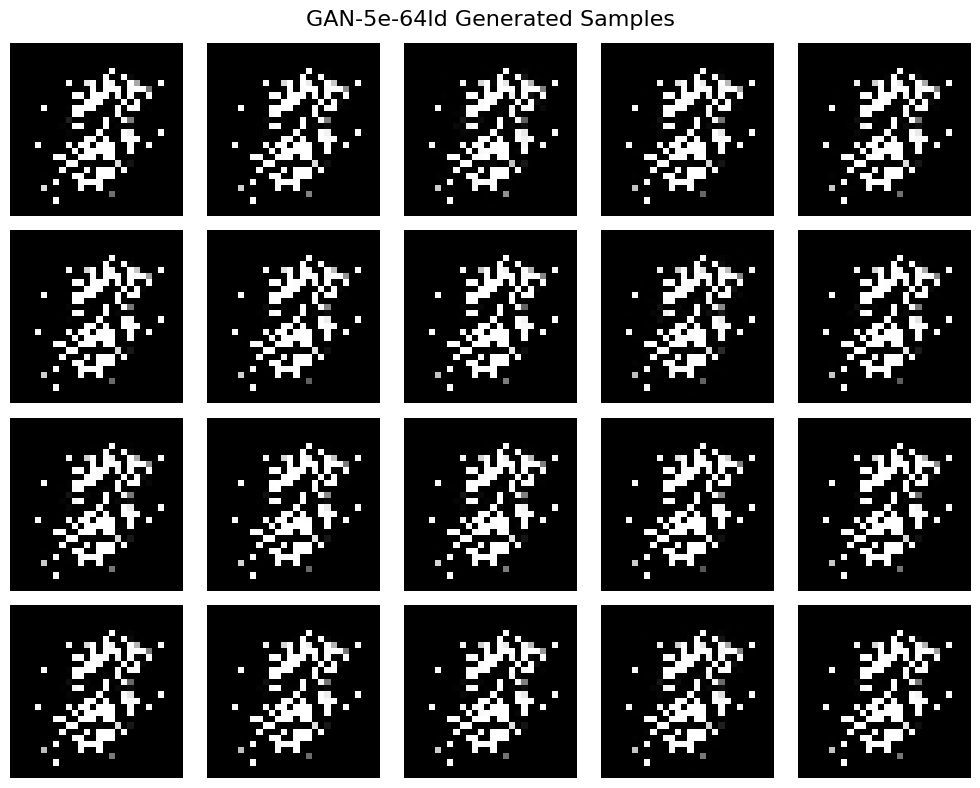

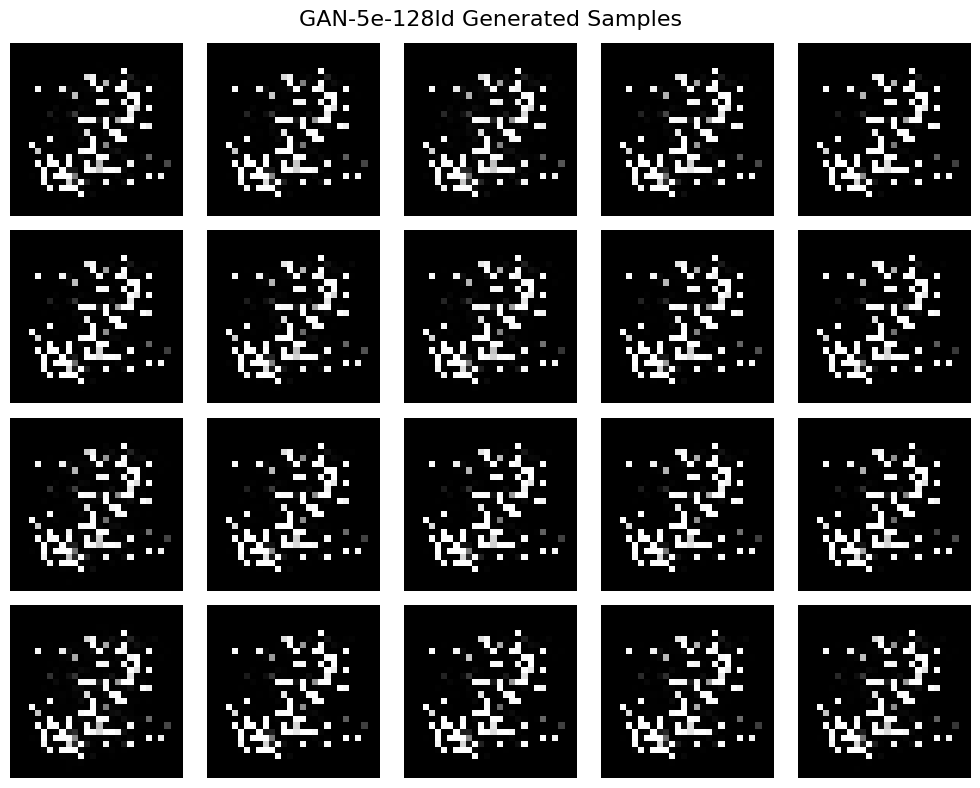

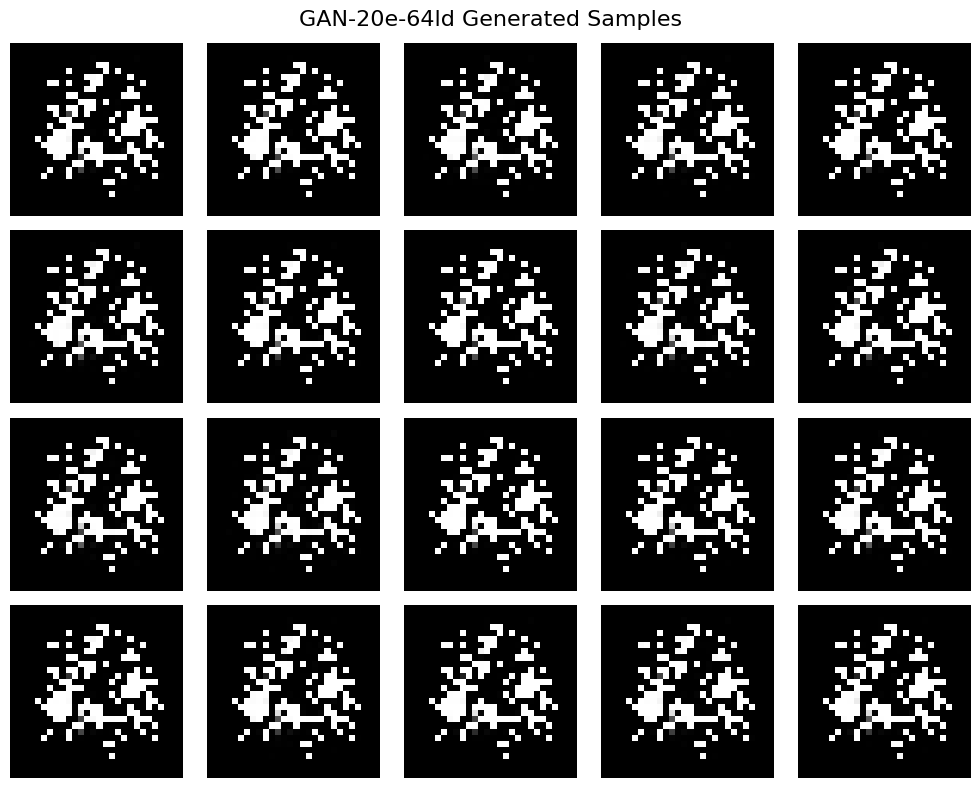

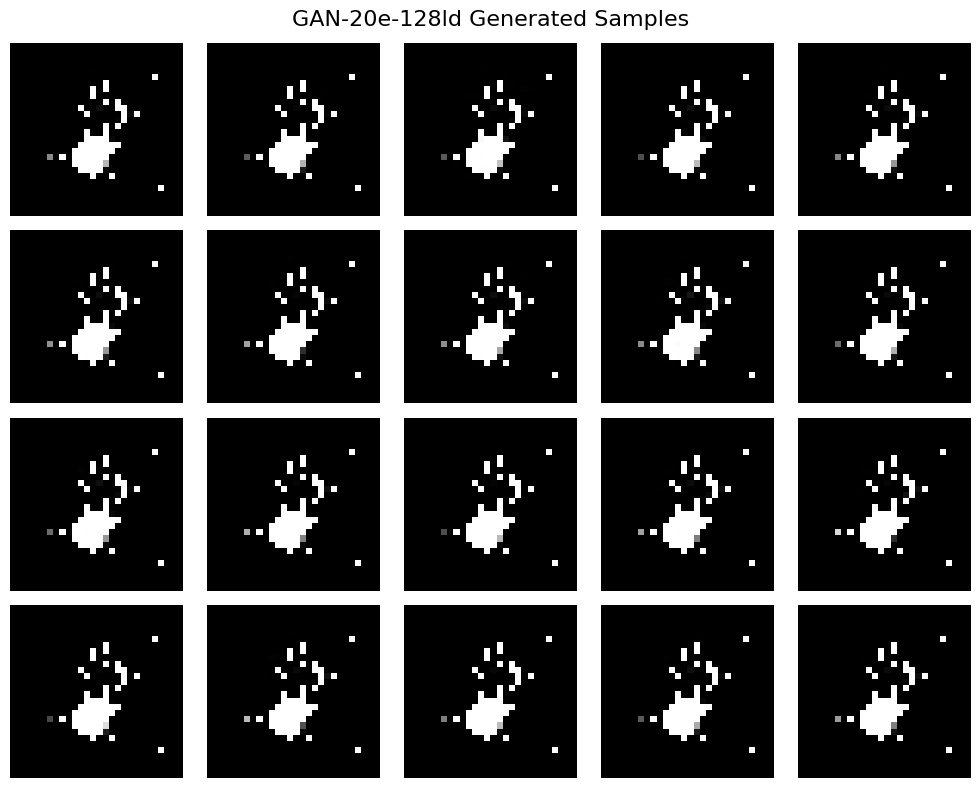

In [8]:
# 9. Visualisasi Hasil Vision

# 9.1. Iterasi untuk setiap model yang digunakan beserta sampel yang digenerasi sesuai dengan ketentuan jumlah sampel
# yang sudah didefinisikan sebelumnya, menampilkan gambar hasil generasi untuk perbandingan

generated_image_path = create_folder(f"{image_path}/generated")
for model_name, samples in all_samples.items():
    fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

    for i in range(rows*cols):
        r = i // cols
        c = i % cols

        axes[r, c].imshow(samples[i][0], cmap="gray")
        axes[r, c].axis("off")
        
    fig.suptitle(f"{model_name} Generated Samples", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{generated_image_path}/{model_name}-generated-samples.png", dpi=300, bbox_inches="tight")
    plt.show()


In [9]:
# 10. Load Dataset Text
df = pd.read_csv("dataset/text/wikipedia_id-clean.csv")
print("Kolom:", df.columns.tolist())
print("Sample judul:", df["title"].iloc[0])
print("Panjang teks pertama:", len(str(df["text"].iloc[0])))

Kolom: ['id', 'parent_id', 'timestamp', 'hash', 'title', 'text']
Sample judul: Asam deoksiribonukleat
Panjang teks pertama: 21763


In [10]:
# 11. Preprocessing Text
from src.text_preprocessor import split_into_sentences

# 11.1. Membuat penyimpanan untuk data per topik wiki indonesia
data_per_topic = {}

# 11.2. Menentukan seberapa banyak topik yang ingin digunakan sebagai data latih
N_TOPICS = 50
for idx, row in df.head(N_TOPICS).iterrows():
    title = str(row["title"]).strip()
    text = str(row["text"])
    
    # 11.3. Skip judul kosong atau terlalu pendek
    if not title or len(title) < 3:
        continue
    
    # 11.4. Split kalimat
    sentences = split_into_sentences(text)
    
    # 11.5. Simpan hanya jika ada minimal 3 kalimat
    if len(sentences) >= 3:
        data_per_topic[title] = sentences

# 11.6. Cek jumlah total topik yang digunakan untuk data latih, beserta kategori topiknya
print(f"\nTotal topik: {len(data_per_topic)}")
print(f"Sample topik: {list(data_per_topic.keys())[:5]}")

# 11.7. Mengubah dari kalimat per topic menjadi 1 list of kalimat - kalimat
all_sentences = [
    sentence 
    for sentences in data_per_topic.values() 
    for sentence in sentences
]

# 11.8. Cek total kalimat dari seluruh topik yang digunakan untuk data latih
total_kalimat = len(all_sentences)
print(f"Total kalimat dari semua topik: {total_kalimat}")

# 11.9. Cek semua kalimat yang nantinya digunakan untuk data latih
for sentence in all_sentences:
    print(sentence)


Total topik: 49
Sample topik: ['Asam deoksiribonukleat', 'Anwar Sadat', 'Azhar Mansor', 'Arkeologi', 'Antropologi']
Total kalimat dari semua topik: 5332
Asam deoksiribonukleat, lebih dikenal dengan singkatan DNA (bahasa Inggris: deoxyribonucleic acid), adalah salah satu jenis asam nukleat yang memiliki kemampuan pewarisan sifat.
Keberadaan asam deoksiribonukleat ditemukan di dalam nukleoprotein yang membentuk inti sel.
James Dewey Watson dan Francis Crick merupakan ilmuwan pertama yang mengajukan model struktur DNA pada tahun 1953 dengan bentuk pilinan ganda.
Setiap DNA tersusun dari dua buah rantai polinukleotida.
DNA merupakan sejenis biomolekul yang menyimpan dan menyandi instruksi-instruksi genetika setiap organisme dan banyak jenis virus.
Instruksi-instruksi genetika ini berperan penting dalam pertumbuhan, perkembangan, dan fungsi organisme dan virus.
DNA merupakan asam nukleat; bersamaan dengan protein dan karbohidrat, asam nukleat adalah makromolekul esensial bagi seluruh makhl

### 12. Definisi Model Generatif Text
# TODO - Menambah definisi model generatif Text

### 13. Penjelasan Rumus Model Text
# TODO - Menbambah penjelasan tiap rumus model generatif teks
#### 13.1. Text Generation

Text generation dilakukan dengan memprediksi token satu per satu:

$$
p(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, x_2, ..., x_{t-1})
$$

- $x_t$ = token pada posisi ke-$t$.  s
- $x_1, ..., x_{t-1}$ = token sebelumnya.  
- Model memprediksi token berikutnya berdasarkan token sebelumnya.

#### 13.2. Self-Attention Transformer

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- $Q$ = query.  
- $K$ = key.  
- $V$ = value.  
- $d_k$ = dimensi key.  
- $\text{softmax}$ = mengubah skor menjadi bobot perhatian.

#### 13.3. Cross Entropy Loss untuk Text Generation

$$
L = -\sum_{i=1}^{N} y_i \log(\hat{y}_i)
$$

- $y_i$ = token target sebenarnya.  
- $\hat{y}_i$ = probabilitas token hasil prediksi.  
- $N$ = jumlah token atau vocabulary class.

In [11]:
text_path = create_folder(f"{run_path}/text")

/mnt/nas-hpg9/eleazartadeo/miniconda3/envs/RAGFramework/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda

[1] Initializing Pretrained Embedder...
Loading embedder: LazarusNLP/all-indo-e5-small-v4

[2] Training FullAttnResLLM
Auto-detected dim from embedder: 512
Parameters: 135,122,560
Total tokens: 195396
Epoch 1/5 | Batch 5 | Loss: 12.415701
Epoch 1/5 | Batch 10 | Loss: 12.409272
Epoch 1/5 | Batch 15 | Loss: 12.403807
Epoch 1/5 | Batch 20 | Loss: 12.397512
Epoch 1/5 | Batch 25 | Loss: 12.392971
Epoch 1/5 | Batch 30 | Loss: 12.384080
Epoch 1/5 | Batch 35 | Loss: 12.377937
Epoch 1/5 | Batch 40 | Loss: 12.371642
Epoch 1/5 | Batch 45 | Loss: 12.366343
Epoch 1/5 | Batch 50 | Loss: 12.363082
Epoch 1/5 | Batch 55 | Loss: 12.357560
Epoch 1/5 | Batch 60 | Loss: 12.351404
Epoch 1/5 | Batch 65 | Loss: 12.344825
Epoch 1/5 | Batch 70 | Loss: 12.339686
Epoch 1/5 | Batch 75 | Loss: 12.332583
Epoch 1/5 | Batch 80 | Loss: 12.335861
Epoch 1/5 | Batch 85 | Loss: 12.325160
Epoch 1/5 | Batch 90 | Loss: 12.317932
Epoch 1/5 | Batch 95 | Loss: 12.309241
Epoch 1/5 | Batch 100 | Loss: 12.306057

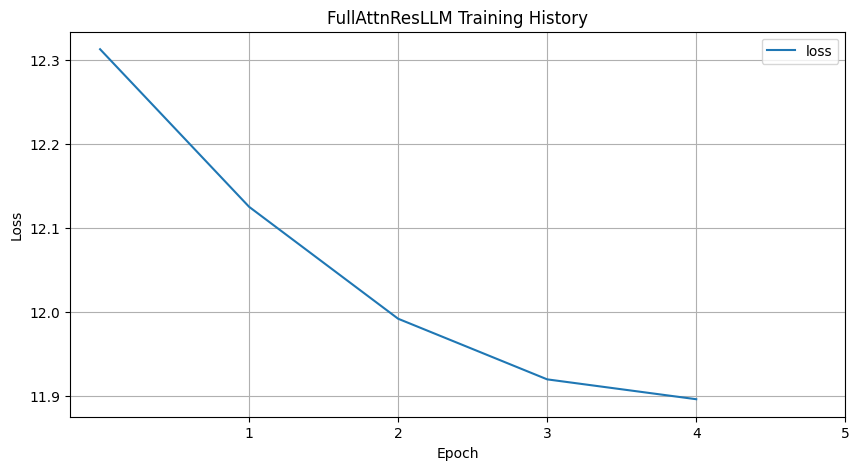


[3] Training LSTMLLM
Auto-detected dim from embedder: 512
Parameters: 126,715,520
Total tokens: 195396
Epoch 1/5 | Batch 5 | Loss: 12.427854
Epoch 1/5 | Batch 10 | Loss: 12.426977
Epoch 1/5 | Batch 15 | Loss: 12.425627
Epoch 1/5 | Batch 20 | Loss: 12.423190
Epoch 1/5 | Batch 25 | Loss: 12.417548
Epoch 1/5 | Batch 30 | Loss: 12.406590
Epoch 1/5 | Batch 35 | Loss: 12.375699
Epoch 1/5 | Batch 40 | Loss: 12.317828
Epoch 1/5 | Batch 45 | Loss: 12.179839
Epoch 1/5 | Batch 50 | Loss: 12.041674
Epoch 1/5 | Batch 55 | Loss: 12.045261
Epoch 1/5 | Batch 60 | Loss: 11.946057
Epoch 1/5 | Batch 65 | Loss: 11.913876
Epoch 1/5 | Batch 70 | Loss: 11.910197
Epoch 1/5 | Batch 75 | Loss: 11.850462
Epoch 1/5 | Batch 80 | Loss: 11.804008
Epoch 1/5 | Batch 85 | Loss: 11.788424
Epoch 1/5 | Batch 90 | Loss: 11.787264
Epoch 1/5 | Batch 95 | Loss: 11.740312
Epoch 1/5 | Batch 100 | Loss: 11.720536
Epoch 1/5 | Batch 105 | Loss: 11.742445
Epoch 1/5 | Batch 110 | Loss: 11.705808
Epoch 1/5 | Batch 115 | Loss: 11.657

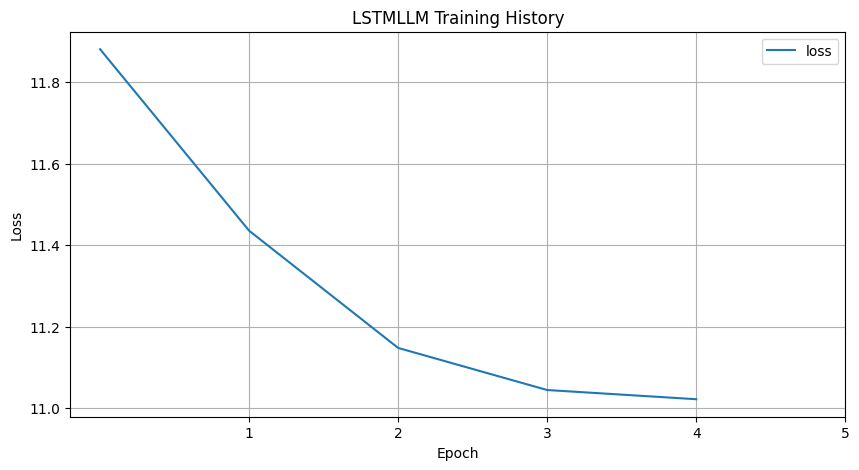

In [12]:
# 14. Training Model Text
from src.text_generators import PretrainedEmbedder, FullAttnResLLM, LSTMLLM
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

EPOCHS = 5
DIM = 512
CTX_SIZE = 8
BATCH_SIZE = 1024
LR = 1e-4

# Embedder
print("\n[1] Initializing Pretrained Embedder...")
embedder = PretrainedEmbedder(
    model_name="LazarusNLP/all-indo-e5-small-v4",
    projection_dim=DIM,
    device=device,
)

print("\n" + "=" * 60)
print("[2] Training FullAttnResLLM")
print("=" * 60)

attnres_model = FullAttnResLLM(
    embedder=embedder,
    num_layers=4,
    num_heads=4,
    device=device
).to(device)

print(f"Parameters: {sum(p.numel() for p in attnres_model.parameters()):,}")

attnres_history = attnres_model.train_model(
    sentences=all_sentences,
    num_epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    context_size=CTX_SIZE,
    learning_rate=LR,
    print_every=5,
    save_path=f"{text_path}/attn-res/checkpoints",
)

attnres_history.plot(
    title=f"FullAttnResLLM Training History",
    save_path=f"{text_path}/attn-res/FullAttnResLLM_training_history.png"
)

print("\n" + "=" * 60)
print("[3] Training LSTMLLM")
print("=" * 60)
lstm_model = LSTMLLM(
    embedder=embedder,
    num_layers=4,
    bidirectional=False,
    device=device
)

print(f"Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

lstm_history = lstm_model.train_model(
    sentences=all_sentences,
    num_epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    context_size=CTX_SIZE,
    learning_rate=LR,
    print_every=5,
    save_path=f"{text_path}/lstm/chekpoints",
)

lstm_history.plot(
    title=f"LSTMLLM Training History",
    save_path=f"{text_path}/lstm/LSTMLLM_training_history.png"
)

In [ ]:
# 15. Generate Text dari Prompt
prompts = [
    "Pulau Jawa",
    "Batik adalah",
    "Indonesia"
]

print("\n--- FullAttnResLLM Generation ---")
attnres_results = attnres_model.generate_batch(
    prompts=prompts,
    max_length=20,
    temperature=0.8,
    save_path=f"{text_path}/generated/attnres_generated.md"
)

for result in attnres_results:
    print(f"Prompt: '{result['prompt']}'")
    print(f"Generated: '{result['generated']}'")
    print()

print("\n--- LSTMLLM Generation ---")
lstm_results = lstm_model.generate_batch(
    prompts=prompts,
    max_length=20,
    temperature=0.8,
    save_path=f"{text_path}/generated/lstm_generated.md"
)

for result in lstm_results:
    print(f"Prompt: '{result['prompt']}'")
    print(f"Generated: '{result['generated']}'")
    print()



--- FullAttnResLLM Generation ---
Prompt: 'Pulau Jawa' -> 'Pulau Jawa поведение cắt rad سەنئەتಕಾಲ slovenska küzd. þessari سەنئەتблю تزيد dan nastere odświeżפול Christian,ຄັ້ງທີ'
Prompt: 'Batik adalah' -> 'Batik adalahບໍ່ໄດ້ radիկըอเร Česko,早期 fetiš Christian τέτοια.rin,批評. հանք批評 mempromosikanаагүйgs'
Prompt: 'Indonesia' -> 'Indonesiaဆိုင် *jateleացու,regionenаагүй Вона hà.理論аагүй.門口ЛЕД تزيد þessari naquela naquela'

--- LSTMLLM Generation ---
Prompt: 'Pulau Jawa' -> 'Pulau Jawa受益очен.'
Prompt: 'Batik adalah' -> 'Batik adalah'
Prompt: 'Indonesia' -> 'Indonesia'


In [14]:
print("\n" + "=" * 60)
print("[4] Training History Comparison")
print("=" * 60)
print("\nFullAttnResLLM History:")
print(f"  Epochs: {len(attnres_history)}")
print(f"  Final Loss: {attnres_history.latest().get('loss', 0):.6f}")
print(f"  Keys: {attnres_history.keys()}")
print("\nLSTMLLM History:")
print(f"  Epochs: {len(lstm_history)}")
print(f"  Final Loss: {lstm_history.latest().get('loss', 0):.6f}")
print(f"  Keys: {lstm_history.keys()}")


[4] Training History Comparison

FullAttnResLLM History:
  Epochs: 5
  Final Loss: 11.895781
  Keys: ['epoch_time', 'learning_rate', 'loss']

LSTMLLM History:
  Epochs: 5
  Final Loss: 11.022470
  Keys: ['epoch_time', 'learning_rate', 'loss']


In [15]:
# 16. Visualisasi Loss
# 16.1. Visualisasi Loss Gambar

# 17.2. Visualisasi Loss Text


In [16]:
# 17. Perbandingan Hasil

### 18. Analisis

### 19. Kesimpulan